# 权重衰退

## 基础知识

权重衰减是正则化技术，防止过拟合。  

权重衰退通过L2正则项使得模型参数不会过大，从而控制模型复杂度

### 均方范数硬性限制  
限制权重平方在阈值内   
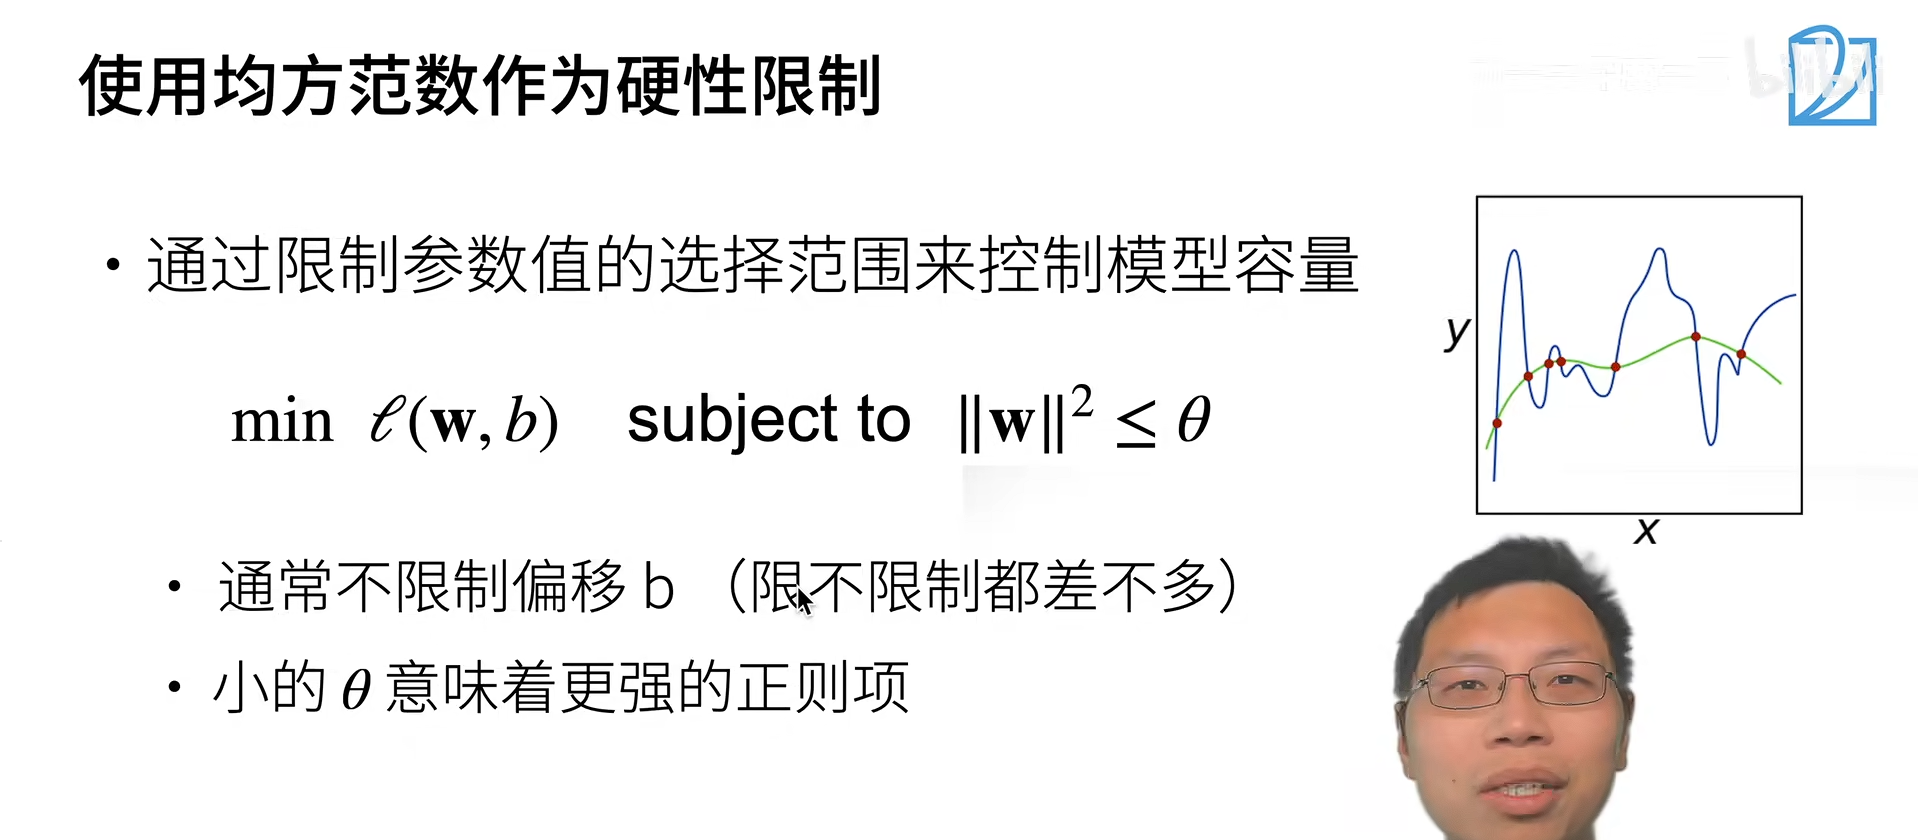

### 均方范数软性限制  
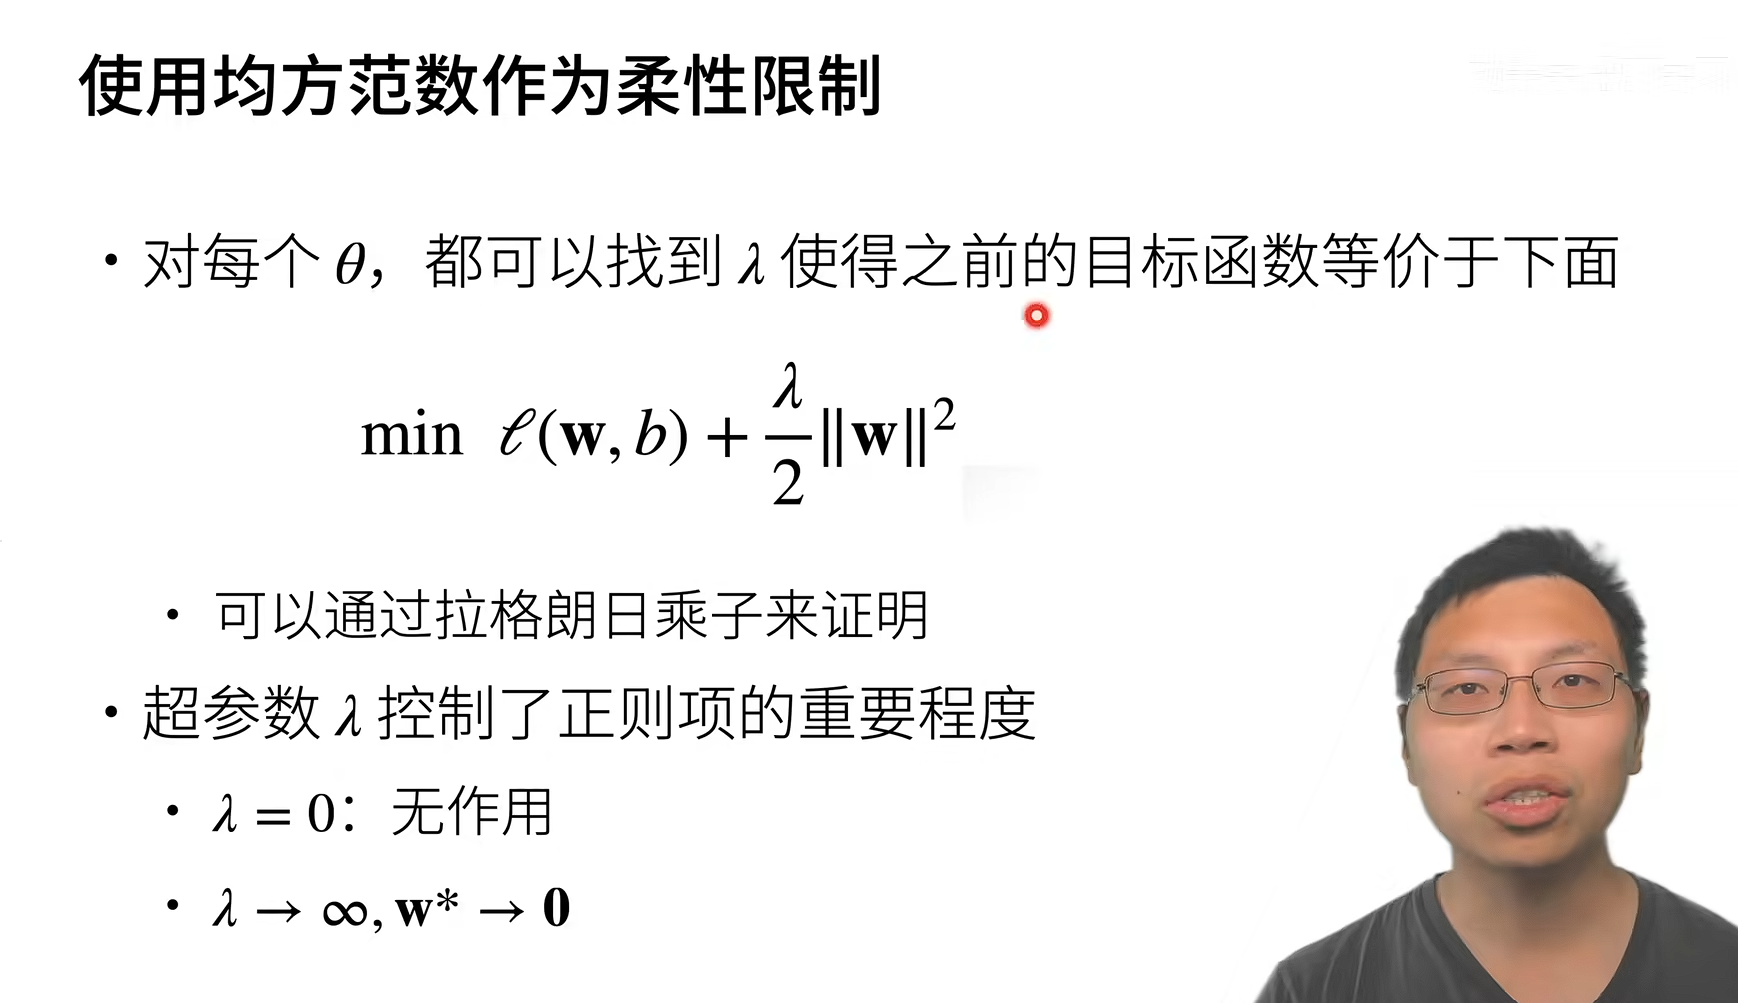

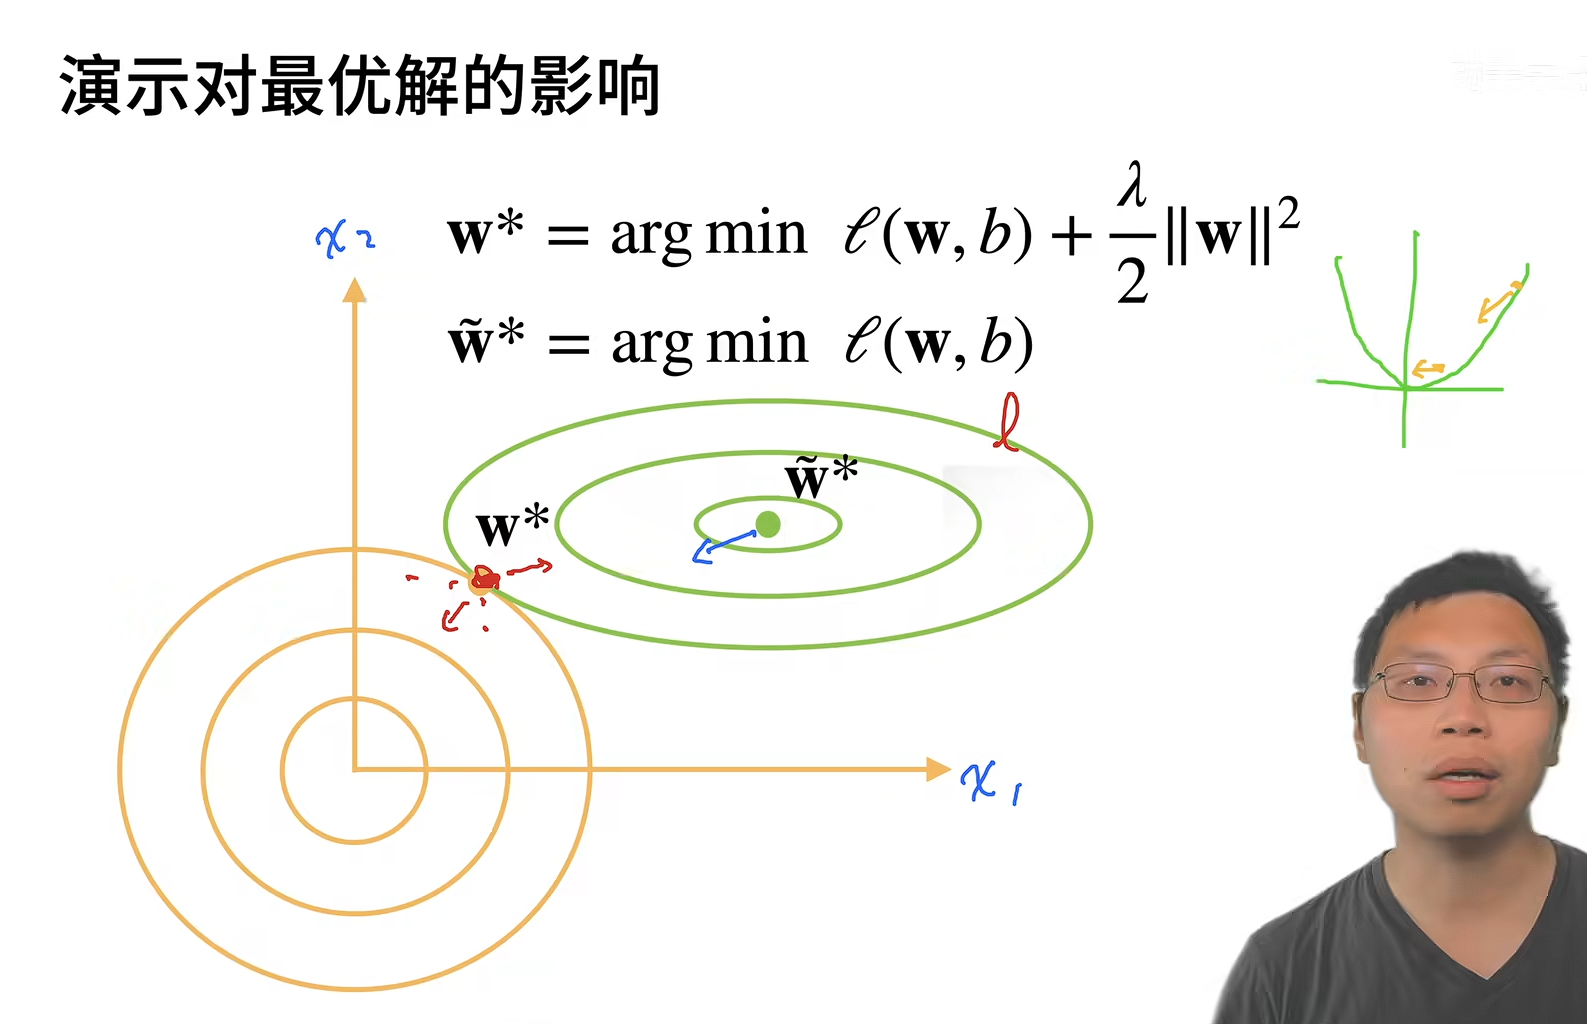

橘线是正则项等高线，绿线是loss的等高线   



可以认为w是一个向量，$w=(x_1,x_2)$往中心拉，$x_1^2+x_2^2$降低，也就是说两个参数的取值范围都小，w取值范围减小   
平衡点处，如果移动，一方减少不足以弥补另一方的增加，所以不应该移动  

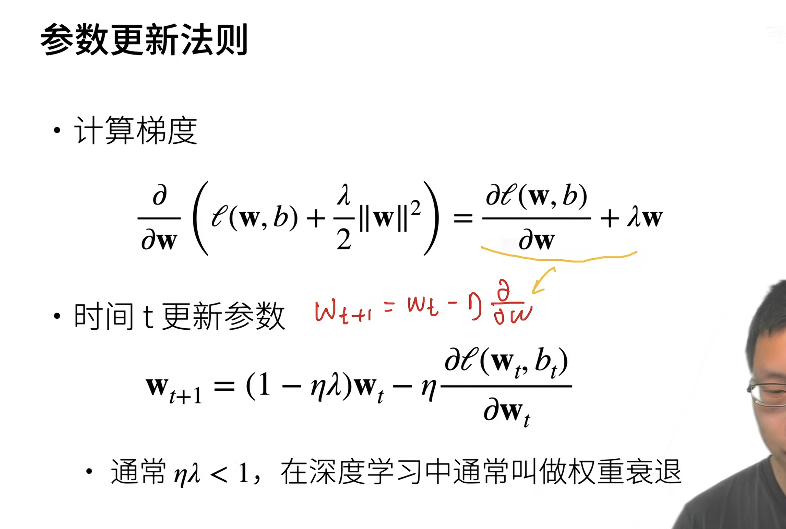

主要变化在 (1-$\eta$ $\lambda$ )，这就是权重衰减

## 代码

### 生成数据集

In [1]:
%matplotlib inline
import torch
from torch import nn
from d2l import torch as d2l
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:
n_train, n_test, num_inputs, batch_size = 20, 100, 200, 5
true_w, true_b = torch.ones((num_inputs, 1)) * 0.01, 0.05
train_data = d2l.synthetic_data(true_w, true_b, n_train)
train_iter = d2l.load_array(train_data, batch_size)
test_data = d2l.synthetic_data(true_w, true_b, n_test)
test_iter = d2l.load_array(test_data, batch_size, is_train=False)

### 初始化

In [3]:
def init_params():
    w = torch.normal(0, 1, size=(num_inputs, 1), requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    return [w, b]

### 权重衰减

In [4]:
def l2_penalty(w):
    return torch.sum(w.pow(2)) / 2

### 训练

In [ ]:
def train(lambd):
    w, b = init_params()
    net, loss = lambda X: d2l.linreg(X, w, b), d2l.squared_loss
    num_epochs, lr = 100, 0.003
    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log',xlim=[5, num_epochs], legend=['train', 'test'])
    for epoch in range(num_epochs):
        for X, y in train_iter:
            # 增加了L2范数惩罚项，
            # ⼴播机制使l2_penalty(w)成为⼀个⻓度为batch_size的向量
            l = loss(net(X), y) + lambd * l2_penalty(w)
            # lambd 的作用是控制模型复杂度的超参数
            l.sum().backward()
            d2l.sgd([w, b], lr, batch_size)
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1, (d2l.evaluate_loss(net, train_iter, loss),d2l.evaluate_loss(net, test_iter, loss)))
    print('w的L2范数是：', torch.norm(w).item())

#### 忽略正则化训练

w的L2范数是： 12.93034553527832


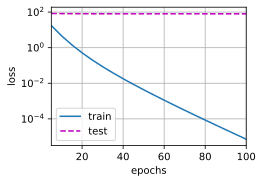

In [6]:
train(lambd=0)

#### 使用权重衰退

w的L2范数是： 0.3617093861103058


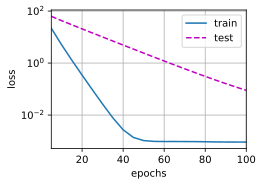

In [7]:
train(lambd=3)

### 简洁实现

 1. 建立网络  
 2. 损失函数  
 3. 优化器（根据反向传播求得梯度 用优化器更具体都来更新参数）  
 4. 从训练集取出数据，进行训练，先梯度清0，算损失，反向传播，然后优化

In [9]:
def train_concise(wd):
    net = nn.Sequential(nn.Linear(num_inputs, 1))
    for param in net.parameters():
        param.data.normal_()
    loss = nn.MSELoss(reduction='none')
    num_epochs, lr = 100, 0.003
    # 偏置参数没有衰减
    trainer = torch.optim.SGD([
    {"params":net[0].weight,'weight_decay': wd},
    # weight_decay是L2范数惩罚项的系数
    {"params":net[0].bias}], lr=lr)
    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log',xlim=[5, num_epochs], legend=['train', 'test'])
    for epoch in range(num_epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.mean().backward()
            trainer.step()
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1,(d2l.evaluate_loss(net, train_iter, loss),d2l.evaluate_loss(net, test_iter, loss)))
    print('w的L2范数：', net[0].weight.norm().item())

w的L2范数： 12.582757949829102


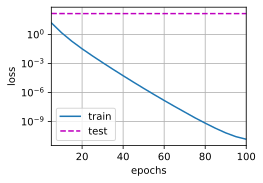

In [10]:
train_concise(0)

w的L2范数： 0.3743467330932617


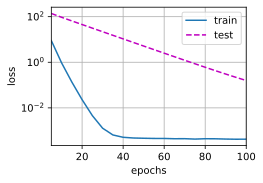

In [11]:
train_concise(3)